In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_rel
import pandas as pd
from pathlib import Path
import scanpy as sc
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from tqdm.notebook import tqdm
import pickle

In [2]:
adata = sc.read_h5ad('../data/simulation/TM_subset_cnt.h5ad')

In [3]:
n_bins = 5

In [4]:
files = Path('../data/simulation/causal_simulation_synthetic').rglob('gwasz__*')
files = [str(file) for file in files]
ground_truth = {}
for file in tqdm(files, total=len(files)):
    setting = Path(file).parent.name
    runid = Path(file).stem.split('__')[1]
    ground_truth[f'{setting}__run-{runid}'] = 'synthetic_cell_type'

  0%|          | 0/5000 [00:00<?, ?it/s]

In [5]:
tc_files = Path('../data/simulation/causal_simulation_synthetic').rglob('tc.pkl')
tc_files = [str(tc_file) for tc_file in tc_files]

ct_size_map = {}
for tc_file in tqdm(tc_files, total=len(tc_files)):
    setting = Path(tc_file).parent.name
    with open(tc_file, 'rb') as f:
        tc = pickle.load(f)

    for i in range(len(tc)):
        colname = f'run_{i}'
        active_cells = tc[i]['active_cells']
        inactive_cells = tc[i]['inactive_cells']
        ct_size_map[f'{setting}__run-{i}'] = active_cells.size + inactive_cells.size

  0%|          | 0/50 [00:00<?, ?it/s]

In [6]:
# load icepop results
files = Path('../results/icepop_casual_mc-75_synthetic_ct').rglob('celltype__trait*.csv')
files = [str(file) for file in files]
dfs = []
for file in tqdm(files, desc="ICePop", total=len(files)):
    file = Path(file)
    setting = file.parent.name
    runid = file.stem.split("__trait-gwasz__")[1].split(".")[0]
    params = {
        k: float(v)
        for k, v in (p.split("-") for p in setting.split("__"))
    }
    
    df = pd.read_csv(
        file,
        usecols=[f"run_{runid}", "q"]
    )
    df = df.rename(columns={f"run_{runid}": 'cell_type'})

    df["target"] = ground_truth[f"{setting}__run-{runid}"]
    df["cell_type_cnts"] = ct_size_map[f"{setting}__run-{runid}"]
    df["run_idx"] = runid
    df["method"] = "ICePop"
    for k, v in params.items():
        df[k] = v
    dfs.append(df)
icepop_res_df = pd.concat(dfs, ignore_index=True)
icepop_res_df['method'] = 'ICePop'

# load seismic results
base_dir = Path("../results/seismic_casual_synthetic_ct")
files = list(base_dir.glob("*.tsv"))
dfs = []
for file in tqdm(files, desc="Seismic", total=len(files)):
    file = Path(file)
    df = pd.read_csv(
        file,
        sep="\t",
        usecols=["cell_type", "FDR"],
    ).rename(columns={"FDR": "q"})
    setting = file.stem
    params = {
        k: float(v)
        for k, v in (p.split("-") for p in setting.split("__"))
    }
    runid = str(int(params.pop("run")))
    aset = setting.split("__run-")[0]
    df["run_idx"] = runid
    df["target"] = ground_truth[f"{aset}__run-{runid}"]
    df["cell_type_cnts"] = ct_size_map[f"{aset}__run-{runid}"]
    df["method"] = "Seismic"
    for k, v in params.items():
        df[k] = v
    dfs.append(df)
seismic_comb_df = pd.concat(dfs, ignore_index=True)

# load scdrs results
base_dir = Path("../results/scdrs_casual_downstream_synthetic_ct")
files = list(base_dir.rglob("*.scdrs_group*"))
dfs = []
for file in tqdm(files, desc="scDRS", total=len(files)):
    file = Path(file)
    df = pd.read_csv(
        file,
        sep="\t",
        usecols=["group", "assoc_mcp"],
    )
    df = df.rename(columns={"group": "cell_type"})
    df["q"] = multipletests(df["assoc_mcp"].values, method="fdr_bh")[1]
    fname = file.name
    setting = fname.split("__run-")[0]
    runid = file.stem.replace(".scdrs_group", "").split("-")[-1]
    params = {
        k: float(v)
        for k, v in (p.split("-") for p in setting.split("__"))
    }
    df["run_idx"] = runid
    df["target"] = ground_truth[f"{setting}__run-{runid}"]
    df["cell_type_cnts"] = ct_size_map[f"{setting}__run-{runid}"]
    df["method"] = "scDRS"
    for k, v in params.items():
        df[k] = v
    dfs.append(df[["cell_type", "q", "target", "run_idx", "cell_type_cnts"] + list(params.keys()) + ["method"]])
scdrs_comb_df = pd.concat(dfs, ignore_index=True)

res_df = pd.concat([icepop_res_df, seismic_comb_df, scdrs_comb_df], axis=0, ignore_index=True)
res_df = res_df[res_df['target'] == res_df['cell_type']]
res_df['discovery'] = res_df['q'] <= 0.1

# divide into cell count bins
bins = pd.qcut(res_df['cell_type_cnts'], q=n_bins, labels=[f"bin_{i+1}" for i in range(n_bins)])
res_df['bins'] = bins.values

# convert sampling rate to heterogeneity level
res_df['hl'] = 1.0 - res_df['sr']
res_df["hl"] = res_df["hl"].round(2)

ICePop:   0%|          | 0/5000 [00:00<?, ?it/s]

Seismic:   0%|          | 0/5000 [00:00<?, ?it/s]

scDRS:   0%|          | 0/5000 [00:00<?, ?it/s]

In [7]:
NOISE_SD_FIXED = 1.0
BETA_FIXED = 1.0
FRAC_SIGNAL_FIXED = 0.01

# experiment D: vary cell sampling rate
HETERO_LIST = [0.0, 0.2, 0.4, 0.6, 0.8]

# plot function

In [8]:
def prepare_plot(res_df, vlabel='hl', bins=None):
    a_df = res_df[
        (res_df['sf'] == FRAC_SIGNAL_FIXED) &
        (res_df['ns'] == NOISE_SD_FIXED) &
        (res_df['b'] == BETA_FIXED) &
        (res_df['hl'].isin(HETERO_LIST))
    ]
    if bins:
        a_df = a_df[a_df['bins'] == bins]
    df = (
        a_df
        .groupby([vlabel, "seed", "method"])["discovery"]
        .mean()
        .rename("power")
        .reset_index()
    )

    return df

def overall_perf(
    res_df, vlabel, outfile,
    xlabel="Signal fraction",
    ylabel="Power",
):

    df = prepare_plot(res_df, vlabel=vlabel)
    stats_results = compute_pairwise_tests(df, x_col=vlabel)

    methods = df["method"].unique()

    plt.figure(figsize=(5, 3.5))

    sns.barplot(
        data=df,
        x=vlabel,
        y="power",
        hue="method",
        errorbar=None,
    )

    sns.stripplot(
        data=df,
        x=vlabel,
        y="power",
        hue="method",
        dodge=True,
        jitter=0.15,
        palette=["black"] * len(methods),
        size=4,
        alpha=0.8,
    )

    ax = plt.gca()

    # Remove duplicate legends
    ax.legend().remove()

    # -------- Add Brackets --------
    # keep y-axis tight
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks(np.linspace(0, 1, 6))
    
    def stars(p):
        if p < 0.001: return "***"
        elif p < 0.01: return "**"
        elif p < 0.05: return "*"
        else: return ""
    
    x_levels = df[vlabel].unique()
    
    # bracket vertical placement in AXES coordinates
    y1 = 1.00   # slightly above axis
    y2 = 1.12
    h = 0.03

    trans = ax.get_xaxis_transform()
    
    for i, xval in enumerate(x_levels):
    
        p12 = stats_results[xval]["p12"]
        p13 = stats_results[xval]["p13"]
    
        # 1 vs 2
        ax.plot([i-0.25, i-0.25, i, i],
                [y1, y1+h, y1+h, y1],
                transform=trans,
                lw=1.5, c="black",
                clip_on=False)
    
        ax.text(i-0.125, y1+h,
                stars(p12),
                ha="center", va="bottom",
                fontsize=12,
                transform=trans,
                clip_on=False)
    
        # 1 vs 3
        ax.plot([i-0.25, i-0.25, i+0.25, i+0.25],
                [y2, y2+h, y2+h, y2],
                transform=trans,
                lw=1.5, c="black",
                clip_on=False)
    
        ax.text(i, y2+h,
                stars(p13),
                ha="center", va="bottom",
                fontsize=12,
                transform=trans,
                clip_on=False)

    # -------- Styling --------
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(-0.05, 1.05)

    ax.set_yticks(np.linspace(0, 1, 6))  # 0, 0.2, ..., 1
    ax.set_yticklabels([f"{x:.1f}" for x in np.linspace(0, 1, 6)])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(outfile)

def split_by_ct_perf(
    res_df, vlabel, outfile,
    xlabel="Signal fraction",
    ylabel="Power", xticks_order=None
):
    fig, axs = plt.subplots(
        ncols=5, nrows=1,
        sharey=True,
        sharex=True,
        figsize=(15, 3.5),
    )

    for i in range(5):
        idx = i + 1
        cur_bin = f"bin_{idx}"

        df = prepare_plot(res_df, vlabel=vlabel, bins=cur_bin)
        stats_results = compute_pairwise_tests(df, x_col=vlabel)

        ax = axs[i]

        # ---- enforce categorical x so positions are 0..K-1 ----
        if xticks_order is None:
            x_order = list(pd.unique(df[vlabel]))
        else:
            x_order = list(xticks_order)

        df = df.copy()
        df["_xcat"] = pd.Categorical(df[vlabel], categories=x_order, ordered=True)

        sns.barplot(
            data=df,
            x="_xcat",
            y="power",
            hue="method",
            errorbar=None,
            ax=ax,
            order=x_order
        )

        sns.stripplot(
            data=df,
            x="_xcat",
            y="power",
            hue="method",
            dodge=True,
            jitter=0.15,
            palette=["black"] * df["method"].nunique(),
            size=3.5,
            clip_on=False,
            ax=ax,
            alpha=0.8,
        )

        # remove duplicate legends
        ax.legend().remove()

        # keep bars within 0–1 and keep ticks 0–1
        ax.set_ylim(-0.03, 1.03)
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        # ---- compute dodge offsets analytically (depends only on #methods) ----
        methods = list(pd.unique(df["method"]))
        n_hue = len(methods)
        total_width = 0.8
        bar_width = total_width / n_hue
        offsets = np.linspace(
            -total_width/2 + bar_width/2,
            total_width/2 - bar_width/2,
            n_hue
        )

        def stars(p):
            if p < 0.001: return "***"
            elif p < 0.01: return "**"
            elif p < 0.05: return "*"
            else: return ""

        # bracket placement (tight) in axes-y coordinates
        y1, y2, h = 1.01, 1.08, 0.02
        trans = ax.get_xaxis_transform()

        # IMPORTANT: iterate categories in the same order as plotted
        x_levels = x_order

        for j, xval in enumerate(x_levels):
            if xval not in stats_results:
                continue

            p12 = stats_results[xval]["p12"]
            p13 = stats_results[xval]["p13"]

            # method centers for this category index j
            x_m1 = j + offsets[0]
            x_m2 = j + offsets[1]
            x_m3 = j + offsets[2]

            # 1 vs 2
            ax.plot([x_m1, x_m1, x_m2, x_m2],
                    [y1, y1+h, y1+h, y1],
                    lw=1.2, c="black", transform=trans, clip_on=False)
            ax.text((x_m1 + x_m2)/2, y1+h, stars(p12),
                    ha="center", va="bottom", fontsize=9,
                    transform=trans, clip_on=False)

            # 1 vs 3
            ax.plot([x_m1, x_m1, x_m3, x_m3],
                    [y2, y2+h, y2+h, y2],
                    lw=1.2, c="black", transform=trans, clip_on=False)
            ax.text((x_m1 + x_m3)/2, y2+h, stars(p13),
                    ha="center", va="bottom", fontsize=9,
                    transform=trans, clip_on=False)

        # titles / labels
        min_cnt = res_df[res_df['bins'] == cur_bin]['cell_type_cnts'].min()
        max_cnt = res_df[res_df['bins'] == cur_bin]['cell_type_cnts'].max()
        title_bin = cur_bin.replace("_", " ")
        ax.set_title(f"Cell type {title_bin}: {min_cnt:,}-{max_cnt:,}", pad=32)

        ax.set_xlabel("")
        if i == 0:
            ax.set_ylabel(ylabel, fontsize=14)
        else:
            ax.set_ylabel("")

        ax.tick_params(axis="x", labelsize=12)
        ax.tick_params(axis="y", labelsize=12)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.subplots_adjust(
        left=0.04,
        right=0.995,
        bottom=0.18,
        top=0.88,
        wspace=0.15
    )
    fig.supxlabel(xlabel, fontsize=14)
    plt.savefig(outfile, bbox_inches="tight")


def compute_pairwise_tests(df, x_col, method_col="method", y_col="power"):
    """
    Compute paired t-tests:
    - first method vs second
    - first method vs third
    
    Returns dictionary:
        {x_level: {"p12": val, "p13": val}}
    """

    results = {}
    methods = df[method_col].unique()

    if len(methods) < 3:
        raise ValueError("Need at least 3 methods for pairwise comparison.")

    for xval in df[x_col].unique():
        sub = df[df[x_col] == xval]

        m1 = sub[sub[method_col] == methods[0]][y_col].values
        m2 = sub[sub[method_col] == methods[1]][y_col].values
        m3 = sub[sub[method_col] == methods[2]][y_col].values

        p12 = ttest_rel(m1, m2).pvalue
        p13 = ttest_rel(m1, m3).pvalue

        results[xval] = {"p12": p12, "p13": p13}

    return results

# experiment D: vary sample rate

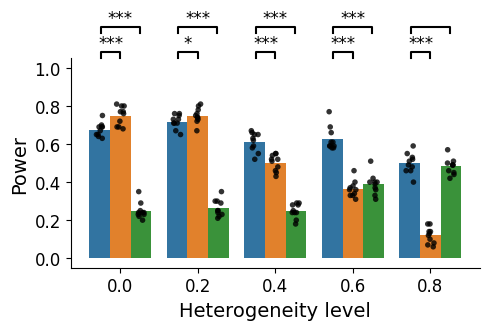

In [13]:
vlabel = 'hl'
overall_perf(
    res_df, vlabel, "../paper/main/causal_hl.pdf",
    xlabel="Heterogeneity level",
    ylabel='Power',
)

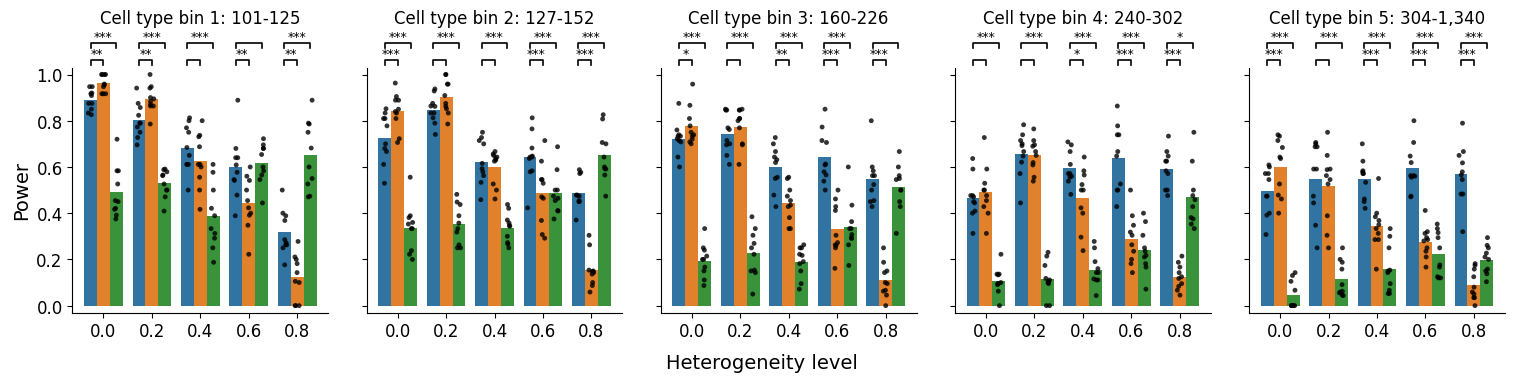

In [12]:
split_by_ct_perf(
    res_df, vlabel,
    "../paper/supp/causal_hl_ctsize.pdf",
    xlabel="Heterogeneity level",
    ylabel='Power',
    xticks_order=[0.0, 0.2, 0.4, 0.6, 0.8]
)